In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')

tips = sns.load_dataset("tips")

#### Data 188 Spring 2024 ####
# Week 11 Seminar Notes #
### A. Adhikari ###
**with William Furtado, Mary Guo (Fall 2022)**

# Multiple Comparisons and ANOVA

We have multiple ways of testing whether two samples come from the same underlying distribution. This week, we will explore techniques for seeing whether several samples come from the same underlying distribution.

But first, we will fill a gap left in an earlier seminar, and define the Kullback Leibler divergence between two distributions. We will also show how it can be used to understand the MLE if the model is misspecified.

## Model Misspecification and KL Divergence

Consider a random variable $X$ that could have one of two probability distributions described by their densities (or pmfs) $g$ and $f$. The [Kullback-Leibler divergence](https://projecteuclid.org/journals/annals-of-mathematical-statistics/volume-22/issue-1/On-Information-and-Sufficiency/10.1214/aoms/1177729694.full) of the two distributions is defined by

$$
D_{KL}(g \Vert f) ~ = ~ \int_x \log\frac{g(x)}{f(x)} \cdot g(x)dx ~ 
= ~ E_g\left( \log \frac{g(X)}{f(X)} \right)
$$

This is a way of measuring how far the two distributions are from each other. You can see from the definition that if $f$ is small where $g$ is large, the KL divergence will be large.

KL divergence has some of the properties of a distance:
- If $g = f$ then $D_{KL}(g \Vert f) = 0$.
- $D_{KL}(g \Vert f) \ge 0$.

The first property is clear from the definition. The second is true by Jensen's inequality.

$$
\begin{align*}
D_{KL}(g \Vert f) ~ &= ~ E_g\left( -\log \frac{f(X)}{g(X)} \right) \\
& \geq -\log\left(E\left(\frac{f(X)}{g(X)}\right)\right) && \text{since } x \to -\log(x) \text{ is convex} \\
&= -\log \int_x \frac{f(x)}{g(x)} \cdot g(x)dx \\
&= -\log \int_x f(x)dx ~ = ~ -\log(1) ~ = ~ 0
\end{align*}
$$

Since $-\log$ is a strictly convex function, equality holds if and only if $f = g$.

But KL divergence is not a distance since in general $D_{KL}(g \Vert f) \neq D_{KL}(f \Vert g)$.

### Misspecified Model ###
Suppose you think that you have an  i.i.d. sample from an underlying parametric family $f(x \mid \theta)$ for some unknown numerical parameter $\theta$. But suppose that in fact the sample consists of i.i.d. draws from $g$ which is not a member of the $f$ family.

For example, suppose you think that your sample is i.i.d. exponential but in fact it's from a gamma distribution with shape parameter $\neq 1$.

To find the MLE of $\theta$, you will look for $\hat{\theta}$ that maximizes 

$$
\frac{1}{n}L(\theta) ~ = ~ \frac{1}{n}\sum_{i=1}^n \log f(X_i \mid \theta)
$$

Since the true underlying distribution is $g$, the WLLN implies

$$
\frac{1}{n}\sum_{i=1}^n \log f(X_i \mid \theta) ~ \xrightarrow{P} ~ E_g(\log f(X \mid \theta))
$$

So for large $n$, the $\hat{\theta}$ that maximizes $\frac{1}{n}L(\theta)$ should with high probability be close to the $\theta^*$ that maximizes $E_g(\log f(X \mid \theta))$. Now 

$$
D_{KL}(g \Vert f_\theta) ~ = ~ E_g(\log g(X)) - E_g(\log f(X \mid \theta))
$$

So

$$
E_g(\log f(X \mid \theta)) ~ = ~ E_g(\log g(X)) - D_{KL}(g \Vert f_\theta)
$$

The first term on the right hand side doesn't involve $\theta$. So finding the $\theta^*$ that *maximizes* the left hand side is equivalent to finding the $\theta^*$ that *minimizes* the KL divergence $D_{KL}(g \Vert f_\theta)$.

In other words, if the MLE $\hat{\theta}$ is computed under the misspecified model, then the estimated distribution $f_\hat{\theta}$ should be close to $f_\theta^*$ which minimizes $D_{KL}(g \Vert f_\theta)$. In this sense, the estimated distribution is the closest you can come to $g$ among members of the family $f_\theta$.

For the hand-wavy argument above to be true, we have to assume smoothness of $f$ and $g$, the existence of a unique MLE under $f_\theta$, and the existence of a unique $\theta^*$ that minimizes $D_{KL}(g \Vert f_\theta)$. There are some other regularity conditions as well. But don't worry about all that. 

## Multiple Comparisons: A Motivating Example

In Data 100, we used **boxplots** to visually compare the difference in distribution of some numerical variable across a finite set of groups. For example, a boxplot could help us visualize the distribution of restaurant bill tips for each day in a week. With assistance from `seaborn`, such a visualization is shown below.

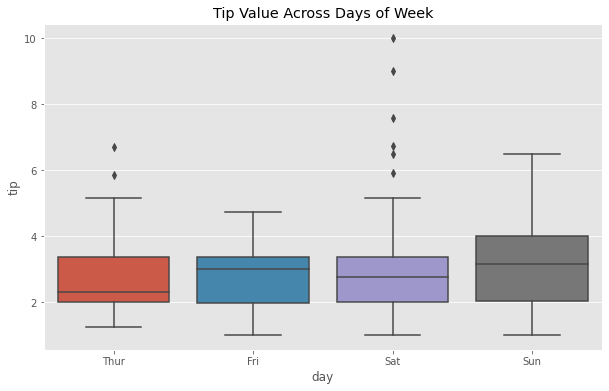

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=tips, x="day", y="tip", ax=ax)
plt.title("Tip Value Across Days of Week");

While this visualization is a necessary first step in comparing the spread of tips across each day, a more formal statistical analysis is needed to answer the following question: "*Do all the boxplots look like they've been drawn from the same distribution*"? 

One way to approach this question is to notice that the variability between group means is an indicator of whether or not all all the groups have the same underlying distribution. A technique know as *Analysis of Variance* (ANOVA) is based on this idea. 

The key to ANOVA is noticing that the variability of our data depend on two factors:

- The variability of the individuals within each group: in the example above, that's the spread in each day's tips. 
- The variability across groups: in the example above, that's the variation across the different days. For example, Thursday's mean looks quite different from Sunday's.

## Analysis of Variance: Deterministic Setting

*Analysis of Variance* is a technique that allows us to answer the question:
> *Do all groups look like they've been drawn from the same distribution?*

To answer this question, we start with a data set that is a list of numbers, with no assumptions about randomness. The data set has been sectioned into a finite number of groups based on a single categorical variable such as "day of the week". 

### Notation

Before diving into the statistical theory, a few notational definitions are in order so that we can keep things organized. Let $y$ be a list of numbers, and define the following.

- $y_{gi} :=$ the $i^{th}$ value in group $g$.
- $G :=$ the number of groups, $1 \leq g \leq G$
- $n_{g} :=$ the number of individuals in group $g$
- $n := \sum_{g=1}^{G} n_{g}$, the number of total individuals

As always, means are of particular interest. Thus, it proves useful to provide short-hand notation for both the *overall mean* for a particular set of data and the *mean of each group*.
- Mean of the all $n$ individuals: $\overline{y}_{..}  := \frac{1}{n}\sum_{g=1}^{G} \sum_{i=1}^{n_{g}} y_{gi}$
- For each $g$, the mean of group $g$: $\overline{y}_{g.} := \frac{1}{n_{g}}\sum_{i=1}^{n_{g}} y_{gi}$
- $Var[y] = \frac{1}{n} \sum_{g=1}^{G} \sum_{i=1}^{n_{g}} (y_{gi} - \overline{y}_{..})^{2}$
- Total sum of squares $SST = n \cdot Var[y] = \sum_{g=1}^{G} \sum_{i=1}^{n_{g}} (y_{gi} - \overline{y}_{..})^{2}$
- For an individual group $g$, the group sum of squares $SST_{g}= \sum_{i=1}^{n_{g}} (y_{gi} - \overline{y}_{..})^{2}$

### Decomposition of $SST$

**Observation:** For any $x_{1}, x_{2}, ..., x_{m} \in \mathbb{R}$, the following result holds for each $c \in \mathbb{R}$:

$$\sum_{i=1}^{m} (x_{i} - c)^{2} = \sum_{i=1}^{m} (x_{i} - \overline{x})^{2} + m(\overline{x} - c)^{2}$$

We can use the above result to decompose $SST_{g}$, the sum of squares total for an individual group $g$. In this case, $c=\overline{y}_{..}$ so that we can reformulate $SST_{g}$ as follows:
$$
SST_g = 
\sum_{i=1}^{n_{g}} (y_{gi} - \overline{y}_{..})^{2} = \sum_{i=1}^{n_{g}} (y_{gi} - \overline{y}_{g.})^{2} + n_{g}(\overline{y}_{g.} - \overline{y}_{..})^{2}
$$

Thus, our original $SST$ decomposes as:

$$ SST = \sum_{g=1}^{G} SST_{g} = \sum_{g=1}^{G}( \sum_{i=1}^{n_{g}} (y_{gi} - \overline{y}_{g.})^{2} + n_{g}(\overline{y}_{g.} - \overline{y}_{..})^{2})$$

Expanding out our double sum, we arrive at the final decomposition of $SST$:

$$SST = \sum_{g=1}^{G} \sum_{i=1}^{n_{g}} (y_{gi} - \overline{y}_{g.})^{2} + \sum_{g=1}^{G} n_{g}(\overline{y}_{g.} - \overline{y}_{..})^{2}$$

It's important to note our assumptions needed to arrive at this result. All we claimed was that $y$ is a list of numbers. 

### Analysis of Variance (ANOVA)
The above decomposition of $SST$ is reminiscent of **variance by conditioning** that we used repeatedly in Data 140. We can break down $SST$ into its two components: $SSW$, the Sum of Squares Within each group and $SSB$, the Sum of Squares Between the groups.

$$SST = SSW + SSB$$
where
$$ SSW = \sum_{g=1}^{G} \sum_{i=1}^{n_{g}} (y_{gi} - \overline{y}_{g.})^{2} $$
$$ SSB = \sum_{g=1}^{G} n_{g}(\overline{y}_{g.} - \overline{y}_{..})^{2} $$

[Recall](http://prob140.org/textbook/content/Chapter_22/03_Variance_by_Conditioning.html#decomposition-of-variance) the formula $Var(Y) = E(Var(Y \mid X)) + Var(E(Y \mid X))$ for a random point $(X, Y)$. In our decomposition we have replaced averages by sums, but the terms are analogous:

- $SST$ is playing the role of $Var(Y)$.
- $SSW$ measures the variability within each group, that is, the variability conditioned on the group. This is playing the role of $E(Var(Y \mid X))$.
- $SSB$ measures the variability of the group means, analogous to $Var(E(Y \mid X))$.

Note that the multiplier of $n_{g}$ acts as a weighting factor for how much each group influences $SSB$.

## Initial Probabilistic Assumptions

Up to this point, we've been working with a list of numbers. Now, let's turn to random variables, leveraging our results above to identify relations between random variables. Since our sum of squares decomposition is true for any sequence of numbers, then it is true for any sequence of random variables as well. The reason is that at each element of the outcome space, the random sequence is just a sequence of numbers.

### Initial Model and the hypotheses 
We define our model as follows.

Assume $Y_{gi} = \mu_{g} + \epsilon_{gi}$, where $\epsilon_{i,j}$ are $iid$ with mean 0 and variance $\sigma^{2}$

It's important to note that we are making no assumptions about the distribution of $Y_{gi}$ other than conditions on the means and variances.

We will hypothesize something simpler than "all $G$ group distributions are the same". We will just test the hypothesis that all $G$ group means are the same.

$$
\begin{align*}
H_{0}: & ~~ \mu_{1} = \mu_{2} = \cdots =\mu_{G} \\
H_{1}: & ~~ \mu_{j} \neq \mu_{k} \text{ for some } j, k \in \{1, 2, \ldots , G\}, j \neq k 
\end{align*}
$$

To build a test statistic, we will start by examining some properties of the sums of squares in our decomposition.

### Expectation of $SSW$

In the Week 11 Discussion worksheet we show that

$$\mathbb{E}[SSW] = \sigma^{2}(n-G)$$

So $\displaystyle{\frac{SSW}{(n-G)}}$ is an unbiased estimator of $\sigma^{2}$. 


### Expectation of $SST$ & $SSB$ under $H_0$

Working under $H_{0}$ provides us with the additional constraint that the underlying means of all the groups must be equal. We can use this fact in conjunction with our previous work in Data 140 to determine the expected value of $SST$ under $H_0$.

By combining this result with $E(SSW)$ calculated above, we can also find the expected value of $SSB$ under $H_0$.

In exercises we will show:

- Under $H_0$, $\mathbb{E}[SST] = \sigma^{2}(n-1)$
- Under $H_0$, $\mathbb{E}[SSB] =  \sigma^{2}(G-1)$

### Building the test statistic

Consider the ratio $\displaystyle{\frac{SSB \big{/} (G-1)}{SSW \big{/} (n-G)}}$.

The denominator is approximately $\sigma^2$. Under $H_0$, the numerator is approximately $\sigma^{2}$ as well. So the statistic should be around $1$ under $H_0$. If its value is much larger than $1$, we will have doubts about whether the null hypothesis is true.

We will now see that if we assume that the errors are normal, then the test statistic has a familiar distribution.

## Probabilistic assumptions: One-Way ANOVA model

**Model:** $Y_{gi} = \mu_{g} + \epsilon_{gi}$, where $\epsilon_{gi}$ are i.i.d. normal $(0, \sigma^{2})$ for all $g$ and $i$.

Therefore for each fixed $g$, the responses $Y_{gi}$ are i.i.d. normal $(\mu_g, \sigma^2)$, and the groups are independent of each other.

The hypotheses are the same as before. The null hypothesis says that all the group means are equal.

$$
\begin{align*}
H_{0}: & ~~ \mu_{1} = \mu_{2} = \cdots =\mu_{G} \\
H_{1}: & ~~ \mu_{j} \neq \mu_{k} \text{ for some } j, k \in \{1, 2, \ldots , G\}, j \neq k 
\end{align*}
$$

We will now examine the distributions of the sums of squares with the goal of understanding the null distribution of our proposed test statistic $\displaystyle{\frac{SSB \big{/} (G-1)}{SSW \big{/} (n-G)}}$.

### Distribution of $SSW$ 

We know 
$$ 
SSW = \sum_{g=1}^{G} SSW_{g} ~~ \text{ where } ~~ SSW_{g} = \sum_{i=1}^{n_{g}} (Y_{gi} - \overline{Y}_{g.})^{2} 
$$

In exercises we will show that under the assumption of normal errors, the distribution of $\displaystyle \frac{1}{\sigma^2} SSW$ is chi-squared with $n-G$ degrees of freedom. 

The heart of the justification is in 
[Data 140 Chapter 23 Ex 6](http://prob140.org/textbook/content/Chapter_23/05_Exercises.html), done in 140 homework. Notice that by chi-squared facts, $E(SSW) = (n-G)\sigma^2$. This is consistent with our expectation calculation earlier in this seminar, when we had not yet assumed normality of the errors.

### Independence of $SSB$ and $SSW$

In exercises we will apply the result of [Data 140 Chapter 23 Exercise 5](http://prob140.org/textbook/content/Chapter_23/05_Exercises.html) (done in 140 homework) to show that $SSB$ and $SSW$ are independent.

### Distribution of $SST$ under $H_0$

Under $H_{0}$, all the $Y$s are i.i.d normal $(\mu, \sigma^{2}$). In exercises, we will apply a Data 140 result linked above to show that under $H_0$, the distribution of $\displaystyle \frac{1}{\sigma^2} SST$ is chi-squared with $n-1$ degrees of freedom.

### Distribution of $SSB$ under $H_0$

Finally, we will show that under $H_0$, the distribution of $\displaystyle \frac{1}{\sigma^2} SSB$ is chi-squared with $G-1$ degrees of freedom.

### Null distribution of the test statistic

The proposed test statistic can be written as

$$
\frac{SSB \big{/} (G-1)}{SSW \big{/} (n-G)} ~ = ~ 
\frac{\frac{1}{\sigma^2} SSB \big{/} (G-1)}{\frac{1}{\sigma^2} SSW \big{/} (n-G)}
$$

- The denominator is a chi-squared $(n-G)$ variable divided by its degrees of freedom.
- The numerator is independent of the denominator.
- Under $H_0$, the numerator is a chi-squared $(G-1)$ variable divided by its degrees of freedom.

Therefore **under $H_{0}$, the test statistic has an $F$ distribution with $G − 1$ and $n - G$ degrees of freedom.**

**Note:** The distribution only depends on the number of groups and the number of total data points. It does not depend on the number of observations in each group.

The denominator of the statistic picks up within-group variability. Under the ANOVA model, each group has the same underlying variance regardless of whether the null hypothesis is true. 

The numerator picks up the variability in the group means. The more they vary, the larger the numerator will be. Therefore large values of the test statistic favor the alternative hypothesis.

## Non-parametric test: Kruskal-Wallis

The One-Way ANOVA Model makes assumptions of normality of the distributions within each group. Such assumptions are strong and may not always reflect the reality of every situation. The *Kruskal-Wallis* test provides a non-parametric alternative to ANOVA that makes no assumptions about normality on the distributions within each group.

**The Model:** We assume $Y_{gi}$ are i.i.d with cdf $F_{g}$ for $1 \le i \le n_g $. Here $F_{g}$ is the CDF for each group $g$. We also assume that the groups are independent of each other.

**Hypotheses:**

\begin{cases} 
     H_{0}:  F_{1} = \ F_{2} = ... =\ F_{G} \\
     H_{1}:  F_{j} \neq F_{k} \text{ for some } j, k \in \{1, 2, ..., G\} & j \neq k\\
\end{cases}

### Idea
For simplicity, we will assume that the data are continuous and we can't have ties.

Combine all the groups and rank all $n$ observations. Construct $\bar{R}_{g.}$ as average rank of group $g$, $g \in \{1, 2, ..., G\}$. Then, we run the traditional ANOVA on the ranks themselves. 

### The $KW$ statistic

Now that we are working exclusively with the *ranks alone*, we can make an important observation about the ANOVA in this case: $SST$ must be a constant. 

In our new notation, we know $\overline{R}_{..} = \frac{n + 1}{2}$ and $SST = \sum_{j=1}^{n}(j - \frac{n+1}{2})^{2} = n⋅(\frac{n^{2}-1}{12})$ using the [variance of the uniform](http://prob140.org/textbook/content/Chapter_12/01_Definition.html#uniform) from Data 140. 

Thus $SSW + SSB$ is a constant and therfore $SSW$ is a function of $SSB$. So we will just use $SSB$ to make our decision.

The *Kruskal-Wallis*, or $KW$, statistic is defined by

$$KW = \frac{12}{n(n+1)} \cdot SSB$$

It can be shown that for large $n$, the null distribution of the $KW$ Statistic is approximately chi-squared with $G - 1$ degrees of freedom. 

In this seminar, we have come up with ways to decide whether or not all groups have the same mean. If our test concludes that they don't, then a natural goal will be to identify which means are different. Next week, we will talk more about how to identify where the difference lies across the groups.